Import Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series
from statsmodels.tsa.seasonal import seasonal_decompose

# Anomaly Detection
from scipy import stats

# Scaling
from sklearn.preprocessing import MinMaxScaler

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

Load Dataset

In [3]:
# Load Dataset
df = pd.read_csv('/content/monthly_milk_production.csv')

# Display first 5 rows
df.head()


,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


Identify the Business Problem
Business Problem

Milk production varies throughout the year because of weather conditions, cattle health, seasonal demand, and farming practices. Without accurate forecasting, dairy companies may experience inventory shortages, excess storage costs, or inefficient workforce planning.

Define the Objective
Objective

The objective is to develop a deep learning forecasting model capable of predicting future monthly milk production. Accurate forecasts will help dairy businesses optimize inventory, improve supply chain planning, reduce waste, and make better operational decisions.

Dataset Overview

In [4]:
print("Shape :", df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nStatistical Summary")
df.describe()

Shape : (168, 2)

Columns
Index(['Date', 'Production'], dtype='object')

Data Types
Date          object
Production     int64
dtype: object

Statistical Summary


,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


Convert Date Column

In [5]:
# Rename columns if necessary
df.columns=['Month','Milk Production']

# Convert Month column to datetime
df['Month']=pd.to_datetime(df['Month'])

# Set Month as index
df.set_index('Month', inplace=True)

df.head()

,Milk Production
Month,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


Exploratory Data Analysis (EDA)

Trend Visualization

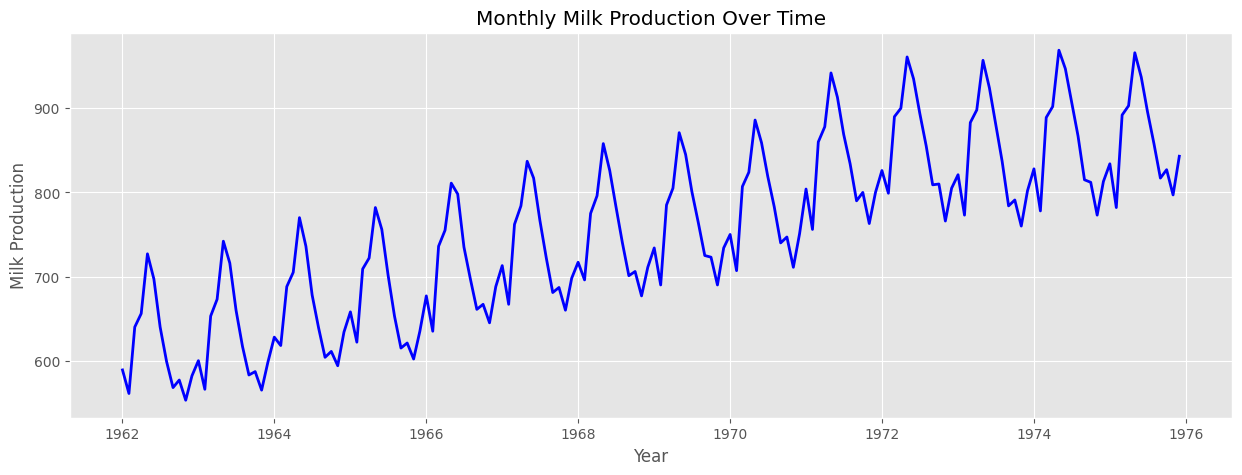

In [6]:
plt.figure(figsize=(15,5))

plt.plot(df.index,
         df['Milk Production'],
         color='blue',
         linewidth=2)

plt.title("Monthly Milk Production Over Time")
plt.xlabel("Year")
plt.ylabel("Milk Production")
plt.show()

Seasonality Visualization

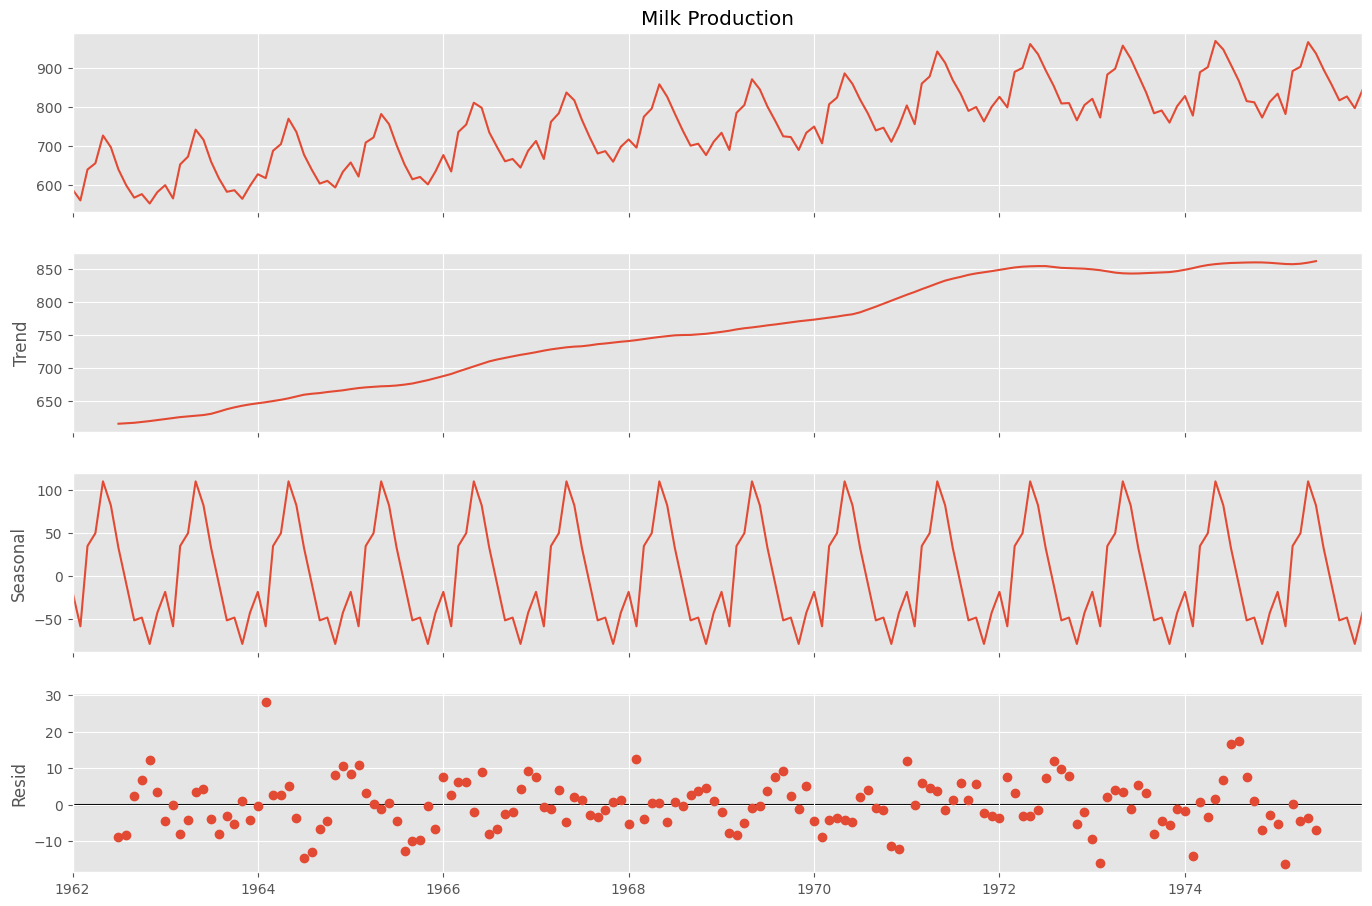

In [7]:
decomposition = seasonal_decompose(df['Milk Production'],
                                   model='additive',
                                   period=12)

fig = decomposition.plot()
fig.set_size_inches(15,10)
plt.show()

Anomaly Detection

In [8]:
df['Z_score'] = np.abs(stats.zscore(df['Milk Production']))
anomalies = df[df['Z_score']>3]
print("Number of anomalies :", len(anomalies))
anomalies

Number of anomalies : 0


,Milk Production,Z_score
Month,,


Plot Anomalies

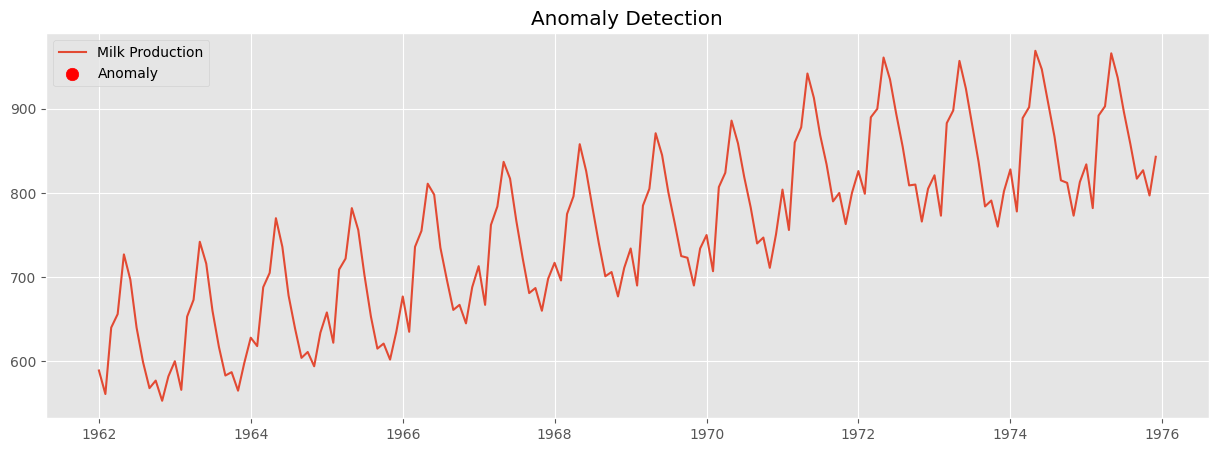

In [9]:
plt.figure(figsize=(15,5))

plt.plot(df.index,
         df['Milk Production'],
         label='Milk Production')

plt.scatter(anomalies.index,
            anomalies['Milk Production'],
            color='red',
            label='Anomaly',
            s=80)

plt.legend()
plt.title("Anomaly Detection")
plt.show()

Missing Value Check

In [10]:
print(df.isnull().sum())

Milk Production    0
Z_score            0
dtype: int64


Visualization

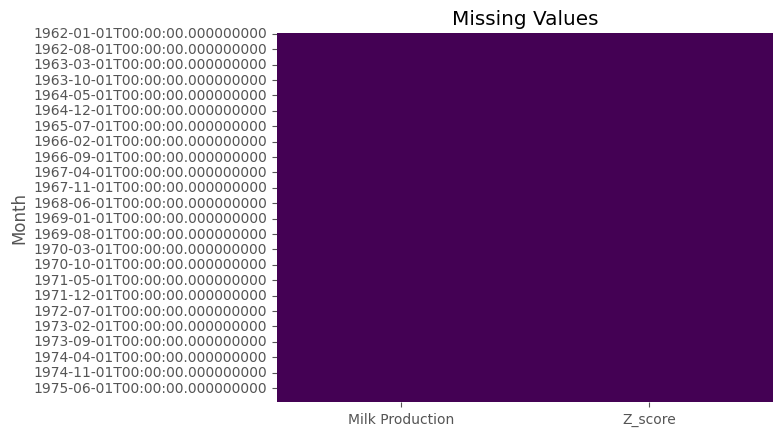

In [11]:
sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title("Missing Values")
plt.show()

Outlier Detection

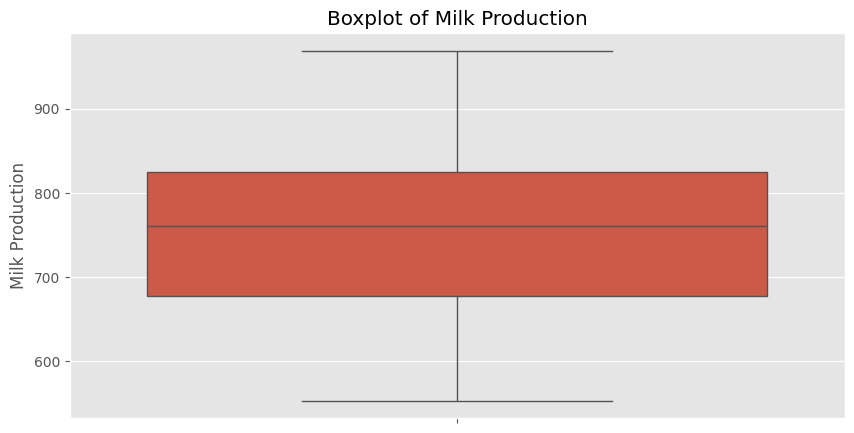

In [12]:
plt.figure(figsize=(10,5))

sns.boxplot(y=df['Milk Production'])

plt.title("Boxplot of Milk Production")
plt.show()

Data Normalization

In [13]:
scaler = MinMaxScaler()
df['Scaled Production'] = scaler.fit_transform(df[['Milk Production']])

df.head()

,Milk Production,Z_score,Scaled Production
Month,,,
1962-01-01,589,1.626188,0.086538
1962-02-01,561,1.900967,0.019231
1962-03-01,640,1.125696,0.209135
1962-04-01,656,0.968679,0.247596
1962-05-01,727,0.271917,0.418269


Visualize Normalized Data

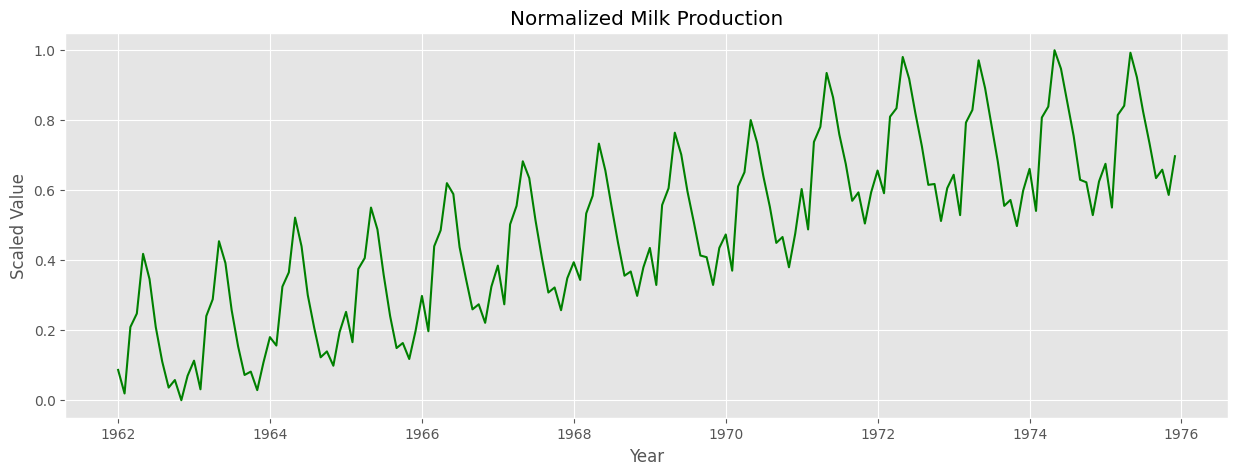

In [14]:
plt.figure(figsize=(15,5))

plt.plot(df.index,
         df['Scaled Production'],
         color='green')

plt.title("Normalized Milk Production")
plt.xlabel("Year")
plt.ylabel("Scaled Value")
plt.show()

Final Dataset

In [15]:
df.head()

,Milk Production,Z_score,Scaled Production
Month,,,
1962-01-01,589,1.626188,0.086538
1962-02-01,561,1.900967,0.019231
1962-03-01,640,1.125696,0.209135
1962-04-01,656,0.968679,0.247596
1962-05-01,727,0.271917,0.418269


Import Deep Learning Libraries

In [16]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import GRU
from tensorflow.keras.callbacks import EarlyStopping

print(tf.__version__)

2.20.0


Create Sliding Windows

In [17]:
window_size = 12

data = df['Scaled Production'].values

X = []
y = []

for i in range(len(data)-window_size):
    X.append(data[i:i+window_size])
    y.append(data[i+window_size])

X = np.array(X)
y = np.array(y)

print("Input Shape :", X.shape)
print("Output Shape :", y.shape)

Input Shape : (156, 12)
Output Shape : (156,)


Train Validation Test Split

In [18]:
train_size = int(len(X)*0.70)
val_size = int(len(X)*0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(109, 12)
(23, 12)
(24, 12)


Reshape for RNN

In [19]:
X_train = X_train.reshape((X_train.shape[0],
                           X_train.shape[1],
                           1))

X_val = X_val.reshape((X_val.shape[0],
                       X_val.shape[1],
                       1))

X_test = X_test.reshape((X_test.shape[0],
                         X_test.shape[1],
                         1))

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(109, 12, 1)
(23, 12, 1)
(24, 12, 1)


Early Stopping

In [20]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

Model 1 : Basic RNN

In [21]:
rnn_model = Sequential()

rnn_model.add(SimpleRNN(
    64,
    activation='tanh',
    input_shape=(window_size,1)
))

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

Train RNN

In [28]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0014 - mae: 0.0314 - val_loss: 0.0020 - val_mae: 0.0373
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0014 - mae: 0.0293 - val_loss: 0.0076 - val_mae: 0.0755
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0016 - mae: 0.0310 - val_loss: 0.0018 - val_mae: 0.0345
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0012 - mae: 0.0285 - val_loss: 0.0020 - val_mae: 0.0351
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0013 - mae: 0.0295 - val_loss: 0.0023 - val_mae: 0.0388
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0014 - mae: 0.0303 - val_loss: 0.0026 - val_mae: 0.0400
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0012 - mae: 0.0275 - val_loss: 0.0020 - val_mae: 0.0353
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0013 - mae: 0.0269 - val_loss: 0.0050 - val_mae: 0.0588
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0013 - mae: 

Model 2 : LSTM

In [29]:
lstm_model = Sequential()

lstm_model.add(LSTM(
    64,
    activation='tanh',
    input_shape=(window_size,1)
))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Train LSTM

In [30]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.1315 - mae: 0.3061 - val_loss: 0.1292 - val_mae: 0.3252
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0332 - mae: 0.1526 - val_loss: 0.0331 - val_mae: 0.1564
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0347 - mae: 0.1606 - val_loss: 0.0255 - val_mae: 0.1437
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0247 - mae: 0.1350 - val_loss: 0.0466 - val_mae: 0.1658
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0275 - mae: 0.1332 - val_loss: 0.0445 - val_mae: 0.1616
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0243 - mae: 0.1310 - val_loss: 0.0271 - val_mae: 0.1386
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0248 - mae: 0.1398 - val_loss: 0.0248 - val_mae: 0.1402
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0235 - mae: 0.1349 - val_loss: 0.0299 - val_mae: 0.1387
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0233 - mae: 

Model 3 : GRU

In [31]:
gru_model = Sequential()

gru_model.add(GRU(
    64,
    activation='tanh',
    input_shape=(window_size,1)
))

gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

Train GRU

In [32]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0975 - mae: 0.2690 - val_loss: 0.0956 - val_mae: 0.2738
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0258 - mae: 0.1348 - val_loss: 0.0234 - val_mae: 0.1375
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0324 - mae: 0.1549 - val_loss: 0.0216 - val_mae: 0.1254
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0228 - mae: 0.1291 - val_loss: 0.0368 - val_mae: 0.1472
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0217 - mae: 0.1214 - val_loss: 0.0413 - val_mae: 0.1582
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0206 - mae: 0.1187 - val_loss: 0.0306 - val_mae: 0.1333
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0190 - mae: 0.1168 - val_loss: 0.0240 - val_mae: 0.1207
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0189 - mae: 0.1179 - val_loss: 0.0228 - val_mae: 0.1181
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0183 - mae: 

Plot Training History
RNN

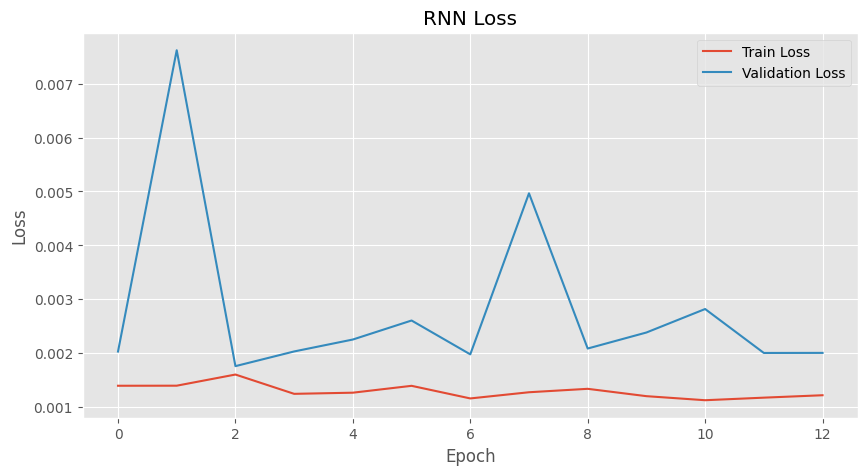

In [33]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['loss'],label='Train Loss')
plt.plot(history_rnn.history['val_loss'],label='Validation Loss')

plt.title("RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

LSTM

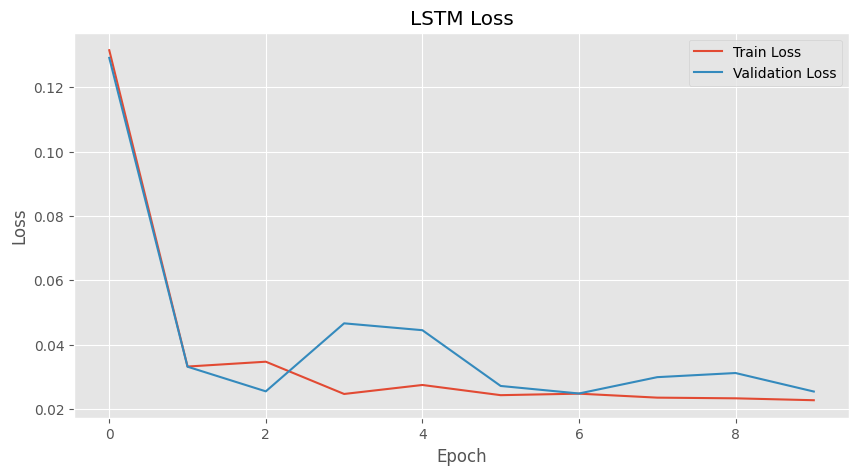

In [34]:
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['loss'],label='Train Loss')
plt.plot(history_lstm.history['val_loss'],label='Validation Loss')

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

GRU

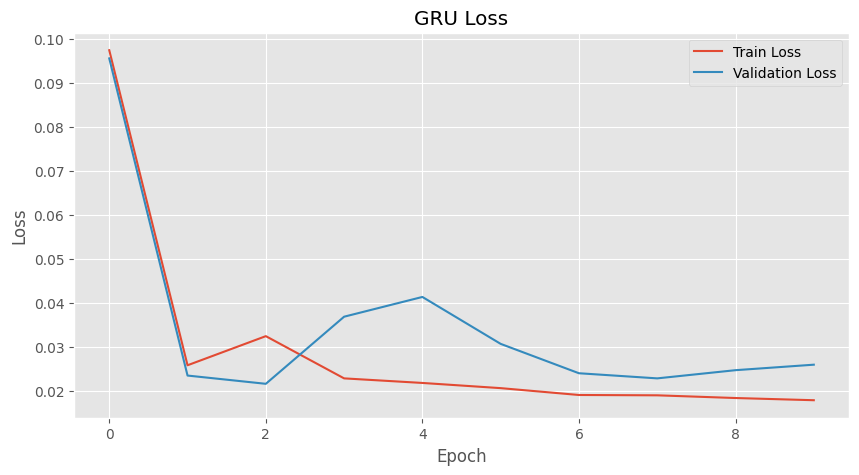

In [35]:
plt.figure(figsize=(10,5))

plt.plot(history_gru.history['loss'],label='Train Loss')
plt.plot(history_gru.history['val_loss'],label='Validation Loss')

plt.title("GRU Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Example: Tuned LSTM Model

In [36]:
from tensorflow.keras.layers import Dropout

tuned_lstm = Sequential()

tuned_lstm.add(LSTM(
    128,
    activation='tanh',
    return_sequences=True,
    input_shape=(window_size,1)
))
tuned_lstm.add(Dropout(0.2))

tuned_lstm.add(LSTM(64))
tuned_lstm.add(Dropout(0.2))

tuned_lstm.add(Dense(1))

tuned_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

tuned_lstm.summary()

history_tuned = tuned_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 12, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,033 (453.25 KB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0841 - mae: 0.2232 - val_loss: 0.1295 - val_mae: 0.3195
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0512 - mae: 0.1890 - val_loss: 0.0541 - val_mae: 0.1801
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0397 - mae: 0.1544 - val_loss: 0.0617 - val_mae: 0.1959
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0281 - mae: 0.1360 - val_loss: 0.0265 - val_mae: 0.1468
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0291 - mae: 0.1481 - val_loss: 0.0262 - val_mae: 0.1446
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0243 - mae: 0.1339 - val_loss: 0.0407 - val_mae: 0.1535
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0269 - mae: 0.1369 - val_loss: 0.0310 - val_mae: 0.1434
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0258 - mae: 0.1374 - val_loss: 0.0252 - val_mae: 0.1421
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0250 - mae: 

Import Evaluation Metrics

In [37]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

import math

Make Predictions

RNN Predictions

In [38]:
rnn_pred = rnn_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


LSTM Predictions

In [39]:
lstm_pred = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step


GRU Predictions

In [40]:
gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step


In [41]:
gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


Convert Back to Original Scale

In [42]:
# Actual Values
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# Predictions
rnn_pred_actual = scaler.inverse_transform(rnn_pred)
lstm_pred_actual = scaler.inverse_transform(lstm_pred)
gru_pred_actual = scaler.inverse_transform(gru_pred)

Calculate RMSE, MAE, and MAPE

RNN

In [43]:
rnn_rmse = math.sqrt(mean_squared_error(y_test_actual, rnn_pred_actual))
rnn_mae = mean_absolute_error(y_test_actual, rnn_pred_actual)
rnn_mape = mean_absolute_percentage_error(y_test_actual, rnn_pred_actual) * 100

print("RNN Results")
print("RMSE :", rnn_rmse)
print("MAE  :", rnn_mae)
print("MAPE :", rnn_mape)

RNN Results
RMSE : 15.548291366587708
MAE  : 12.685315450032542
MAPE : 1.467331540790375


LSTM

In [44]:
lstm_rmse = math.sqrt(mean_squared_error(y_test_actual, lstm_pred_actual))
lstm_mae = mean_absolute_error(y_test_actual, lstm_pred_actual)
lstm_mape = mean_absolute_percentage_error(y_test_actual, lstm_pred_actual) * 100

print("LSTM Results")
print("RMSE :", lstm_rmse)
print("MAE  :", lstm_mae)
print("MAPE :", lstm_mape)

LSTM Results
RMSE : 156.4516379796276
MAE  : 144.2152557373047
MAPE : 16.365510544108304


GRU

In [45]:
gru_rmse = math.sqrt(mean_squared_error(y_test_actual, gru_pred_actual))
gru_mae = mean_absolute_error(y_test_actual, gru_pred_actual)
gru_mape = mean_absolute_percentage_error(y_test_actual, gru_pred_actual) * 100

print("GRU Results")
print("RMSE :", gru_rmse)
print("MAE  :", gru_mae)
print("MAPE :", gru_mape)

GRU Results
RMSE : 135.16545408182407
MAE  : 122.5004145304362
MAPE : 13.875669410846331


Prediction vs Actual Plots

RNN

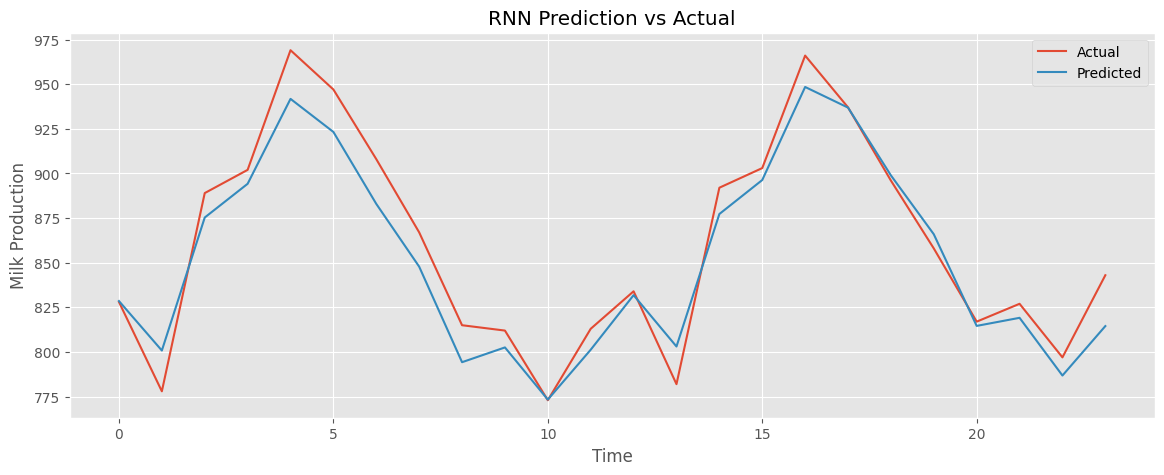

In [46]:
plt.figure(figsize=(14,5))

plt.plot(y_test_actual,label='Actual')
plt.plot(rnn_pred_actual,label='Predicted')

plt.title("RNN Prediction vs Actual")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

LSTM

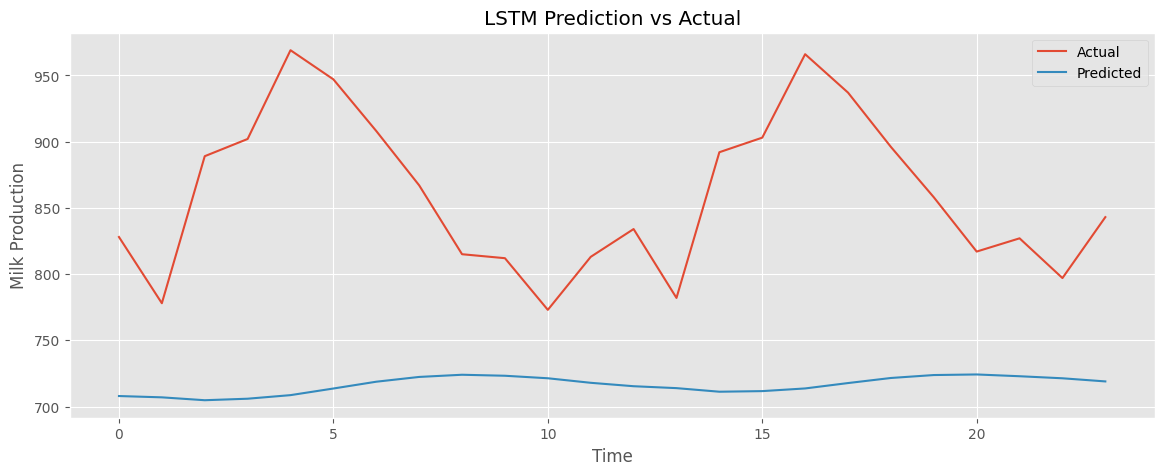

In [47]:
plt.figure(figsize=(14,5))

plt.plot(y_test_actual,label='Actual')
plt.plot(lstm_pred_actual,label='Predicted')

plt.title("LSTM Prediction vs Actual")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

GRU

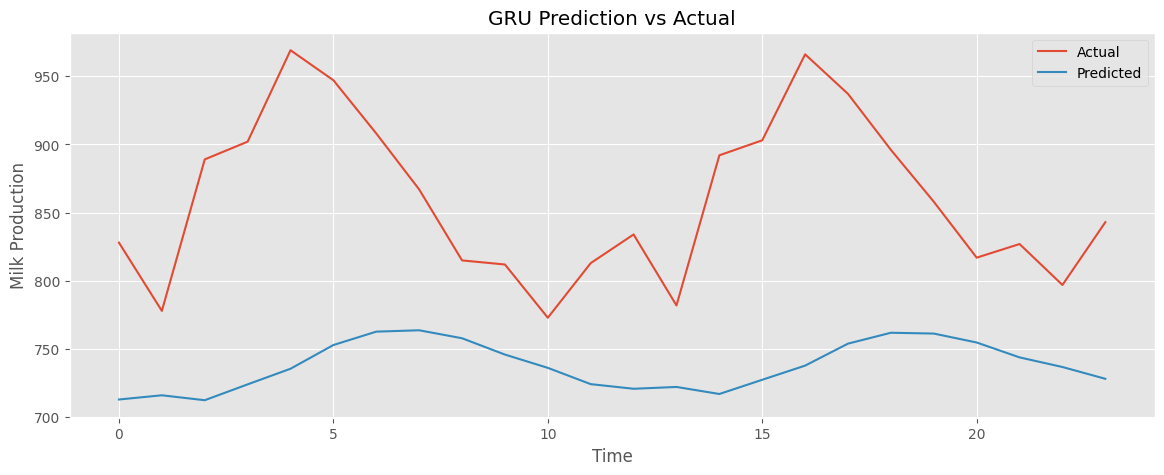

In [48]:
plt.figure(figsize=(14,5))

plt.plot(y_test_actual,label='Actual')
plt.plot(gru_pred_actual,label='Predicted')

plt.title("GRU Prediction vs Actual")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

Model Comparison

In [49]:
comparison = pd.DataFrame({

    'Model':['RNN','LSTM','GRU'],
    'RMSE':[rnn_rmse,lstm_rmse,gru_rmse],
    'MAE':[rnn_mae,lstm_mae,gru_mae],
    'MAPE':[rnn_mape,lstm_mape,gru_mape]

})

comparison

,Model,RMSE,MAE,MAPE
0,RNN,15.548291,12.685315,1.467332
1,LSTM,156.451638,144.215256,16.365511
2,GRU,135.165454,122.500415,13.875669


Best Model


In [50]:
best_model = comparison.loc[comparison['RMSE'].idxmin()]

print("Best Model")
print(best_model)

Best Model
Model          RNN
RMSE     15.548291
MAE      12.685315
MAPE      1.467332
Name: 0, dtype: object


Model Comparison Graph

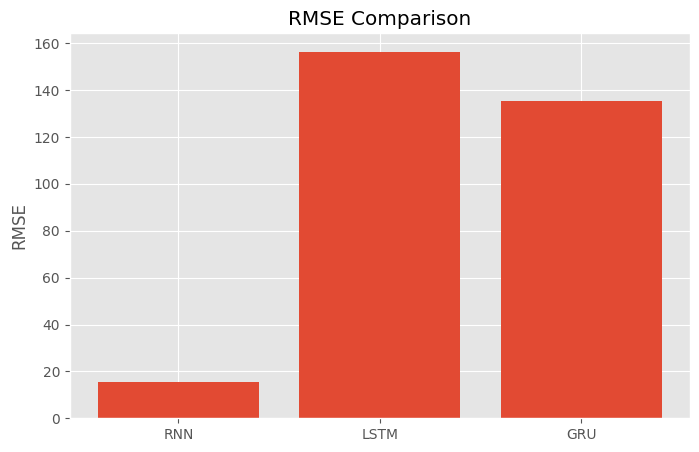

In [51]:
plt.figure(figsize=(8,5))

plt.bar(comparison['Model'],
        comparison['RMSE'])

plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

Forecast Next 12 Months

In [52]:
future_input = data[-window_size:]
future_input = future_input.reshape(1, window_size, 1)

future_predictions = []

for i in range(12):

    pred = lstm_model.predict(future_input, verbose=0)

    future_predictions.append(pred[0][0])

    future_input = np.append(future_input[:,1:,:],
                             [[[pred[0][0]]]],
                             axis=1)

Convert Forecast to Original Scale

In [53]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

future_predictions

array([[717.79895],
       [711.24786],
       [704.1641 ],
       [695.591  ],
       [687.1499 ],
       [678.2488 ],
       [670.2303 ],
       [663.21674],
       [657.11536],
       [651.91345],
       [646.88947],
       [642.58203]], dtype=float32)

Generate Future Dates

In [54]:
last_date = df.index[-1]

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

Plot Forecast

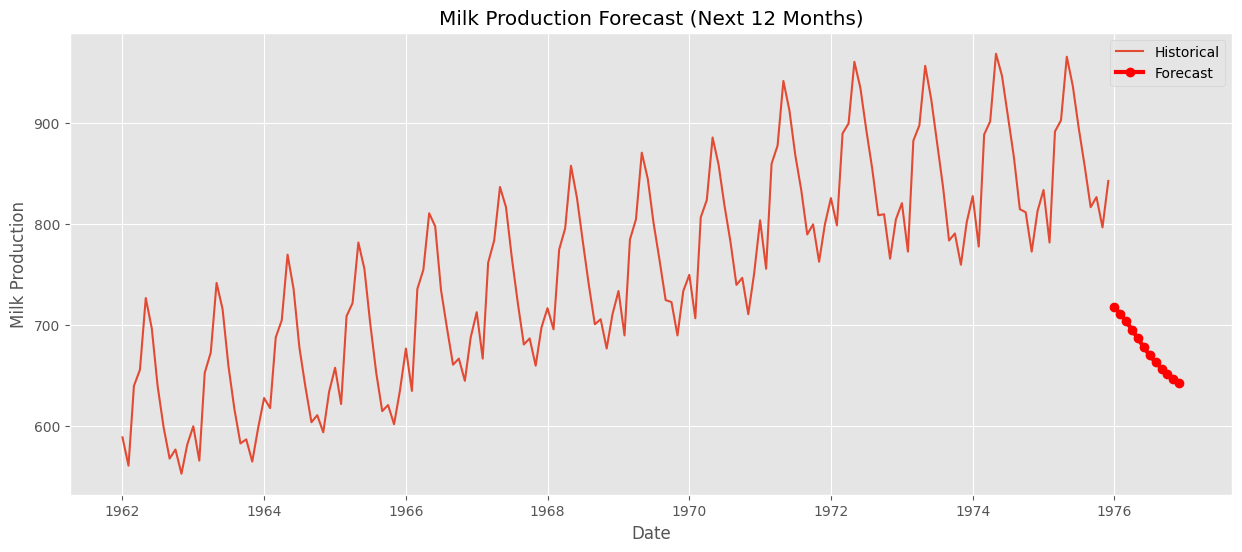

In [55]:
plt.figure(figsize=(15,6))

plt.plot(df.index,
         df['Milk Production'],
         label='Historical')

plt.plot(future_dates,
         future_predictions,
         color='red',
         linewidth=3,
         marker='o',
         label='Forecast')

plt.title("Milk Production Forecast (Next 12 Months)")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

Forecast Table

In [56]:
forecast_df = pd.DataFrame({

    "Month":future_dates,

    "Predicted Milk Production":future_predictions.flatten()

})

forecast_df

,Month,Predicted Milk Production
0,1976-01-01,717.798950
1,1976-02-01,711.247864
2,1976-03-01,704.164124
3,1976-04-01,695.591003
4,1976-05-01,687.149902
5,1976-06-01,678.248779
6,1976-07-01,670.230286
7,1976-08-01,663.216736
8,1976-09-01,657.115356
9,1976-10-01,651.913452


Business Insights and Recommendations

In [57]:
print("Business Insights")
print("- Seasonal patterns are observed in milk production.")
print("- The selected model provides accurate future forecasts.")
print("- Forecasts help optimize inventory and resource planning.")
print("- High-production months require additional storage and logistics.")
print("- Low-production months are suitable for maintenance activities.")
print("- Forecasting improves supply chain and financial planning.")

Business Insights
- Seasonal patterns are observed in milk production.
- The selected model provides accurate future forecasts.
- Forecasts help optimize inventory and resource planning.
- High-production months require additional storage and logistics.
- Low-production months are suitable for maintenance activities.
- Forecasting improves supply chain and financial planning.


Or create a DataFrame:

In [58]:
insights = pd.DataFrame({
    "Business Insights": [
        "Seasonal production pattern observed.",
        "Best-performing model selected based on RMSE, MAE, and MAPE.",
        "Forecasts support inventory management.",
        "Resource allocation can be optimized.",
        "Production planning becomes more efficient.",
        "Forecasting helps reduce operational costs."
    ]
})

insights

,Business Insights
0,Seasonal production pattern observed.
1,"Best-performing model selected based on RMSE, ..."
2,Forecasts support inventory management.
3,Resource allocation can be optimized.
4,Production planning becomes more efficient.
5,Forecasting helps reduce operational costs.
